# Ocean Wind 1

In [1]:
from time import perf_counter
from pathlib import Path

import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

from whale import Project

%load_ext autoreload
%autoreload 2

pd.options.display.float_format = "{:,.4f}".format
pd.options.display.max_rows = 1000
pd.options.display.max_columns = 100

## Configure the models

In [2]:
library_path = Path("library").resolve()
orbit_config = "Ocean_Wind_1_base_install.yaml"
wombat_config = "Ocean_Wind_1_base_operations.yaml"
floris_config = "Ocean_Wind_1_base_floris_gch.yaml"

weather_df = pd.read_csv(
    library_path / "weather" / "ocean_wind_1_39.0_-74.0_1959_2023.csv",
    # engine="pyarrow",
    parse_dates=["datetime"],
    infer_datetime_format=True,
    index_col="datetime",
    dtype=float,
)

In [3]:
project = Project(
    library_path=library_path,
    weather=weather_df,
    orbit_weather_cols=["windspeed_10m", "windspeed_100m", "wave_height"],
    floris_windspeed="windspeed_100m",
    floris_wind_direction="wind_direction_100m",
    orbit_config=orbit_config,
    wombat_config=wombat_config,
    floris_config=floris_config,
)

ORBIT library intialized at '/Users/rhammond/Documents/GitHub/WHaLE/examples/library'
Correcting negative Overhang:-2.5


In [4]:
# THIS IS ONLY FOR CORRECTING THE DATA IF IT'S NEEDED
# DO NOT RUN UNLESS YOU NEED TO OVERWRITE THE WEATHER PROFILES

# import datetime
# import pandas as pd

# weather_df = pd.read_csv(
#     library_path / "weather" / "ocean_wind_1_39.0_-74.0_1959_2023_UTC.csv",
#     engine="pyarrow",
#     parse_dates=["datetime"],
#     index_col="datetime",
#     dtype=float,
# )
# weather_df.index = pd.to_datetime(weather_df.index).tz_localize("UTC") - datetime.timedelta(hours=5)
# weather_df.head()

# # full
# fn = library_path / "weather" / "ocean_wind_1_39.0_-74.0_1959_2023.csv"
# weather_df.loc["1/1/1959":].to_csv(fn, index_label="datetime", date_format="%m/%d/%Y %H:%M")

# # WOMBAT
# fn = library_path / "weather" / "ocean_wind_1_39.0_-74.0_1959_2023_wombat.csv"
# weather_df.loc["1/1/1959":, ["windspeed", "wave_height"]].to_csv(fn, index_label="datetime", date_format="%m/%d/%Y %H:%M")

# # ORBIT
# fn = library_path / "weather" / "ocean_wind_1_39.0_-74.0_1959_2023_orbit.csv"
# weather_df.loc["1/1/1959":, ["windspeed_100m", "windspeed_10m", "wave_height"]].to_csv(fn, index_label="datetime", date_format="%m/%d/%Y %H:%M")

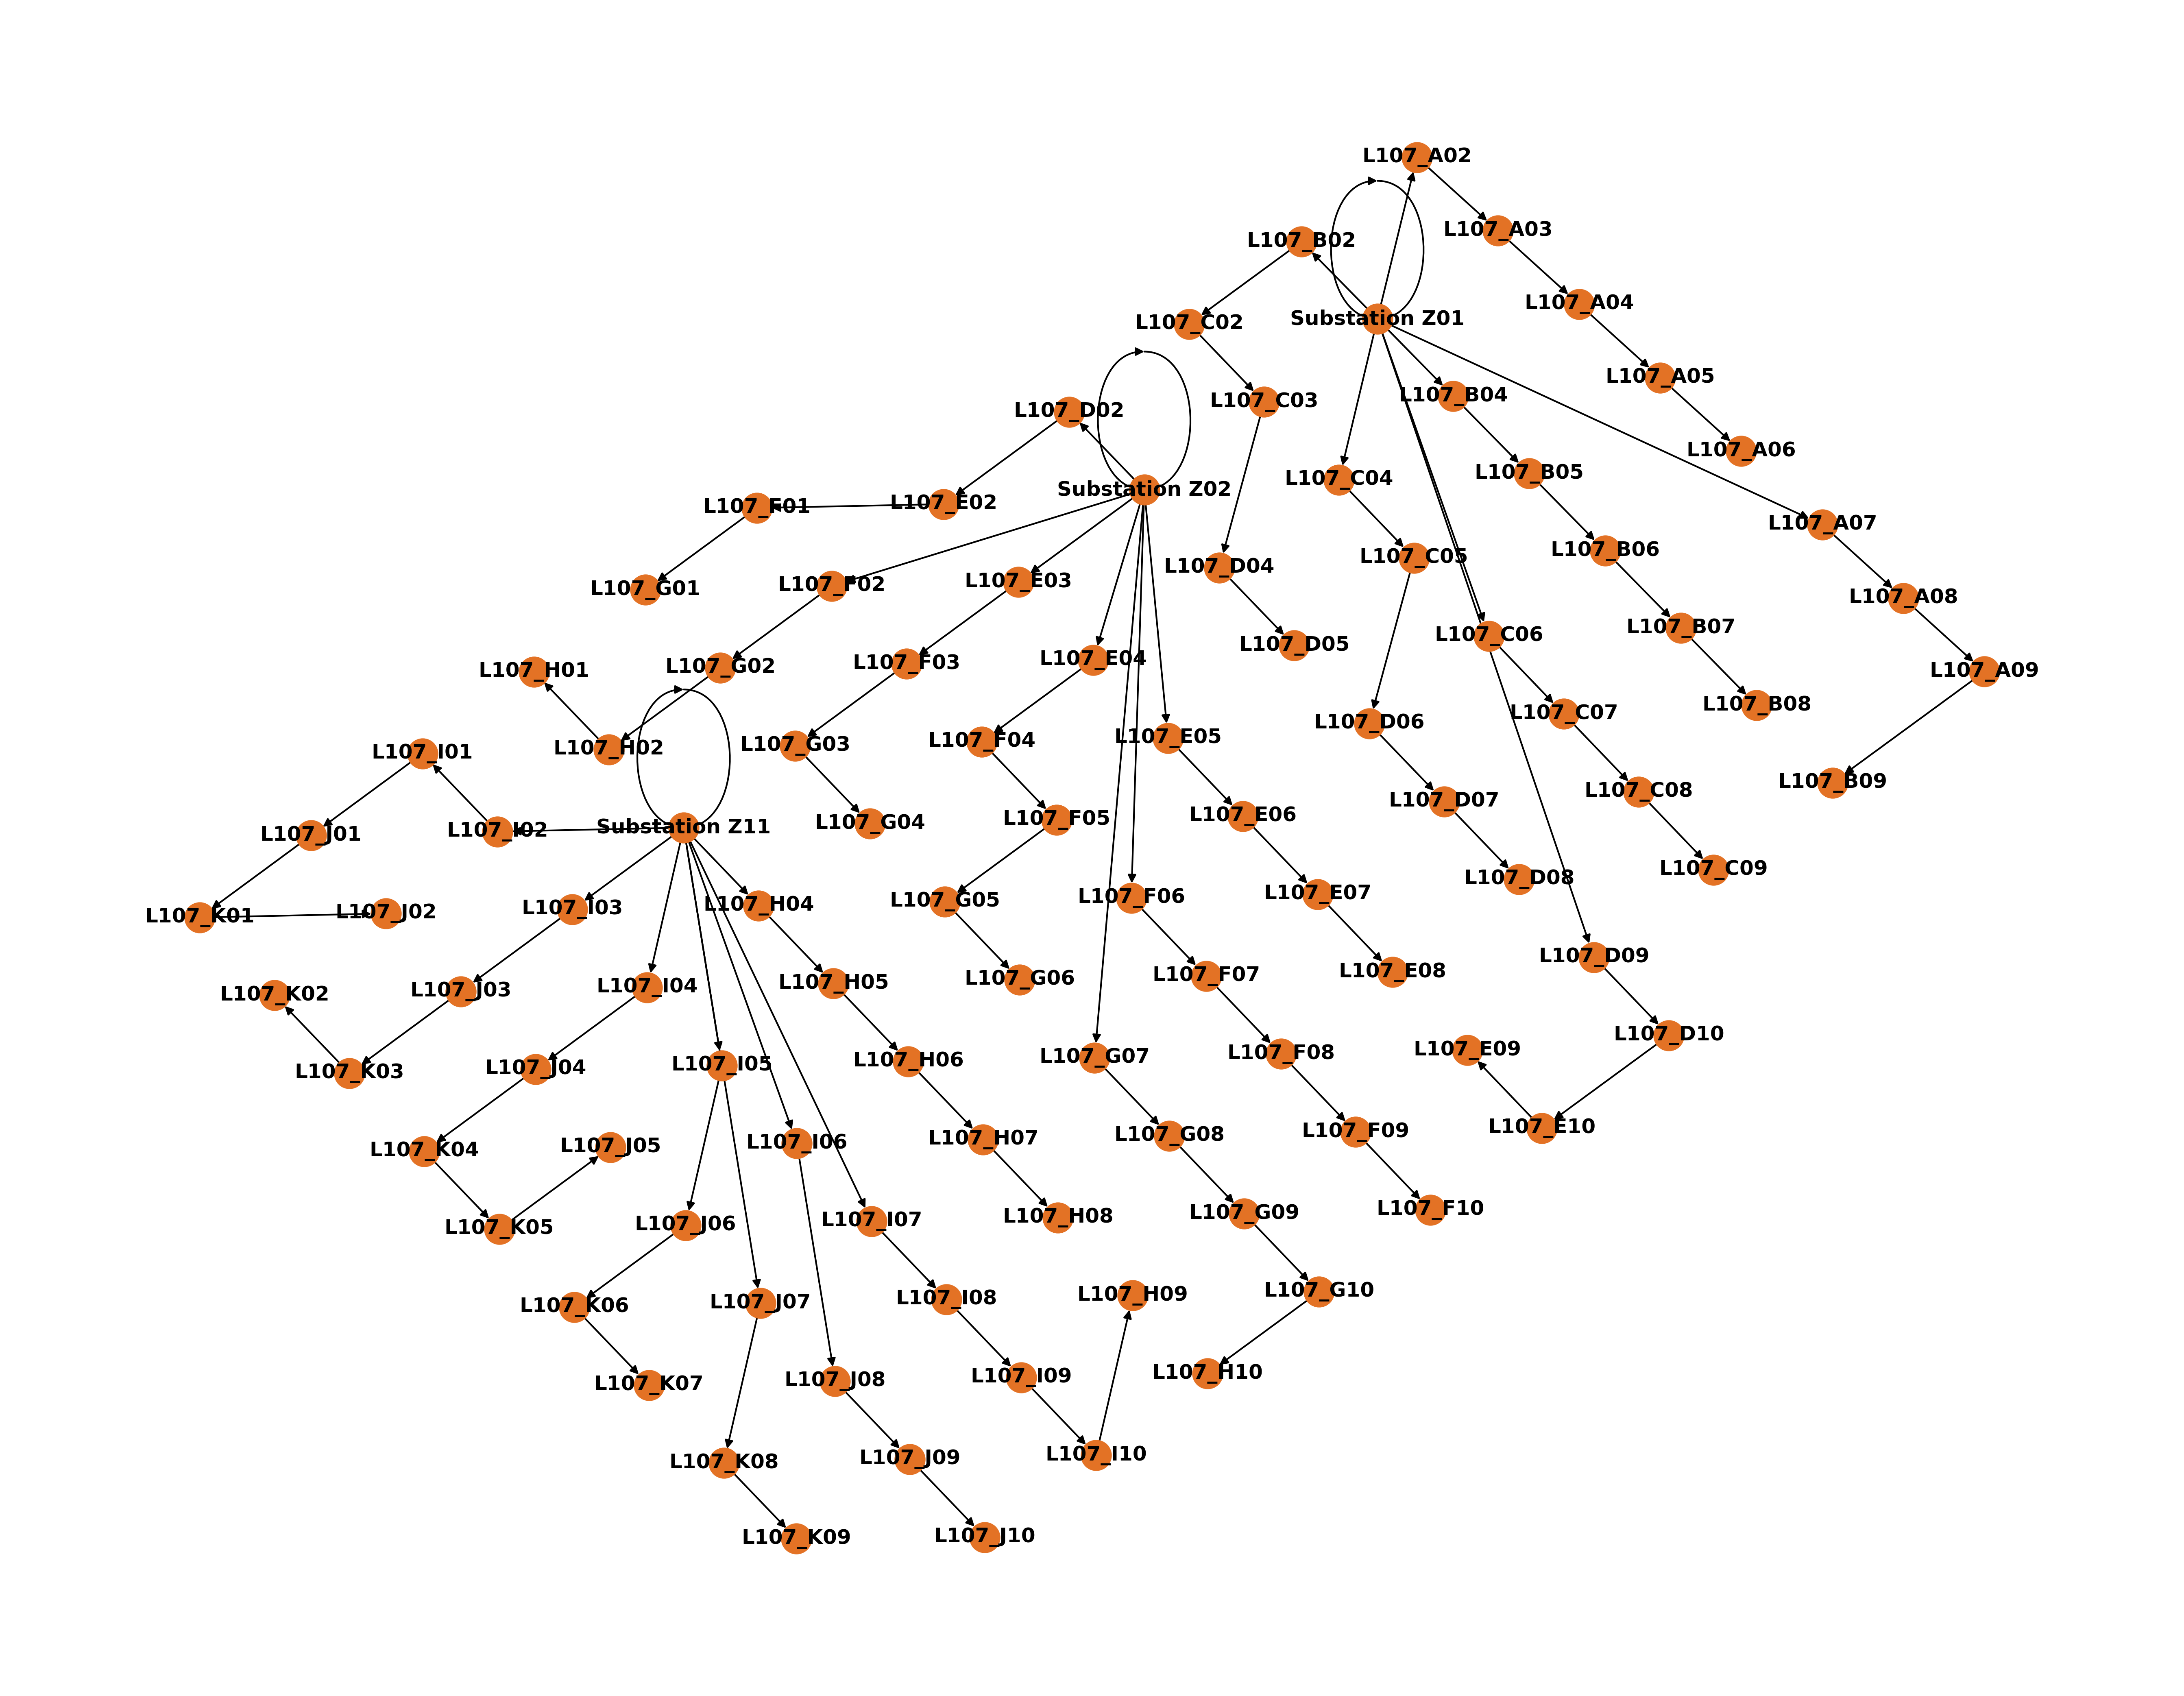

In [5]:
fig = plt.figure(figsize=(18, 14), dpi=300)
ax = fig.add_subplot(111)

windfarm = project.wombat.windfarm
positions = {name: np.array([node["longitude"], node["latitude"]]) for name, node in windfarm.graph.nodes(data=True)}
nx.draw(windfarm.graph, with_labels=True, font_weight="bold", pos=positions, ax=ax, node_color="#E37225")

fig.tight_layout()

In [6]:
# Recalibrate the coordinates to smaller and anonymized distance-based coordinates from the lower left hand corner of the wind farm

layout = project.wombat.windfarm.layout_df.copy()
if layout.floris_x.isnull().sum() == layout.shape[0] or layout.floris_y.isnull().sum() == layout.shape[0]:
    min_x = layout.easting.min()
    min_y = layout.northing.min()

    layout.floris_x = layout.easting - min_x
    layout.floris_y = layout.northing - min_y
    layout.to_csv("library/project/plant/ocean_wind_1_layout_base.csv", index=False)
    
    # Reinitialize FLORIS with the new layout coordinates that are tied back to WOMBAt
    floris_x, floris_y = layout.loc[layout.type == "turbine", ["floris_x", "floris_y"]].values.T
    project.floris.reinitialize(layout_x=floris_x, layout_y=floris_y)

    # Open the floris configuration the floris configuration
    import yaml
    
    with open(library_path / "project/config" / floris_config, "r") as f:
        floris_config_dict = yaml.safe_load(f)

    # Update the layout parameters and re-save
    floris_config_dict["farm"]["layout_x"] = floris_x.tolist()
    floris_config_dict["farm"]["layout_y"] = floris_y.tolist()

    with open(library_path / "project/config" / floris_config, 'w') as f:
        yaml.dump(floris_config_dict, f, default_flow_style=False)
        
layout.head()

,id,substation_id,name,type,latitude,longitude,string_actual,order_actual,string,order,distance,subassembly,upstream_cable,easting,northing,floris_x,floris_y
0,L107_A02,Substation Z01,L107_A02,turbine,39.2083,-74.1932,0.0000,2.0000,0.0000,0.0000,NaN,12MW_100pct_reduction.yaml,array.yaml,569658,4340200,15390,20167
1,L107_E05,Substation Z02,L107_E05,turbine,39.1321,-74.2298,0.0000,0.0000,0.0000,0.0000,NaN,12MW_100pct_reduction.yaml,array.yaml,566568,4331721,12300,11688
2,L107_H04,Substation Z11,L107_H04,turbine,39.1102,-74.2901,0.0000,0.0000,0.0000,0.0000,NaN,12MW_100pct_reduction.yaml,array.yaml,561380,4329242,7112,9209
3,L107_A03,Substation Z01,L107_A03,turbine,39.1987,-74.1812,0.0000,1.0000,0.0000,1.0000,NaN,12MW_100pct_reduction.yaml,array.yaml,570699,4339141,16431,19108
4,L107_E06,Substation Z02,L107_E06,turbine,39.1219,-74.2188,0.0000,1.0000,0.0000,1.0000,NaN,12MW_100pct_reduction.yaml,array.yaml,567530,4330594,13262,10561


## Run the analyses and calculate results

`project.run()` calls the following methods:
- `project.orbit.run()` where `project.orbit` is ORBIT's `ProjectManager`
- `project.wombat.run()` where `project.wombat` is WOMBAT's `Simulation`
- `project.floris.run()` where `project.floris` is FLORIS's `FlorisInterface` and run does one of the following:
  - calculates the "wind_rose" AEP value based on the full weather profile (`project.weather`)
  - calculates the "time_series" AEP value over the WOMBAT simulation period, which calculates the hourly turbine powers for the farm

### TODO

- Bifurcate the new weather data for 10m/100m data for ORBIT and 100m data for WOMBAT/FLORIS to see if that resolves the ORBIT run issues
- Tie the FLORIS/WOMBAT outputs together
- 

In [7]:
# FLORIS FOR TIME SERIES FOR 20 YEARS

# project.run(which_floris="wind_rose", floris_kwargs=dict(cut_in_wind_speed=3.0, cut_out_wind_speed=25.0))

start = perf_counter()
project.orbit.run()
end = perf_counter()
print(f"ORBIT run time: {(end - start) / 60:5,.2f} minutes")

start = perf_counter()
project.wombat.run()
end = perf_counter()
print(f"WOMBAT run time: {(end - start) / 60:5,.2f} minutes")

start = perf_counter()
project.run_floris(which="wind_rose", reinitialize_kwargs=dict(cut_in_wind_speed=3.0, cut_out_wind_speed=25.0))
end = perf_counter()
print(f"FLORIS wind rose run time: {(end - start) / 60:5,.2f} minutes")
print(f"{project.aep_mwh.sum() / 20 / 1e3:,.2f} GWh")

start = perf_counter()
project.run_floris(which="time_series", nodes=8)
end = perf_counter()
print(f"FLORIS timeseries run time: {(end - start) / 60:5,.2f} minutes")

print(f"{project.floris_turbine_powers.values.sum() / 20 / 1e6:,.2f} GWh")
print(f"{project.aep_mwh / 1e3:,.2f} GWh")

ORBIT run time:  0.17 minutes
WOMBAT run time:  1.54 minutes
FLORIS wind rose run time:  2.07 minutes
248.11 GWh


Calculating turbine-level power: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████| 252/252 [1:35:14<00:00, 22.68s/it]


FLORIS timeseries run time: 95.30 minutes
5,218,498,774.04 GWh


TypeError: unsupported format string passed to Series.__format__

In [8]:
print(f"{project.floris_turbine_powers.values.sum() / 20 / 1e9:,.2f} GWh")

5,218.50 GWh


In [ ]:
print(f"CapEx: ${project.orbit.bos_capex / 1e6:,.2f} M")
print(f"CapEx: ${project.orbit.bos_capex_per_kw:,.2f}/kW")
capex_df = pd.DataFrame.from_dict(
    project.orbit.capex_breakdown, orient="index"
).rename(columns={0: "CapEx ($)"}).join(
    pd.DataFrame.from_dict(project.orbit.capex_breakdown_per_kw, orient="index").rename(columns={0: "CapEx ($/kW)"})
)
capex_df

In [ ]:
project.wombat.metrics.time_based_availability("project", "windfarm")

In [ ]:
# OpEx, in millions, annually
project.wombat.metrics.opex(frequency="annual") / 1e6

In [ ]:
project.wombat.env.cleanup_log_files()

In [11]:
turbine_powers = project.floris_turbine_powers
availability = project.wombat.metrics.operations

In [19]:
layout = project.wombat.windfarm.layout_df
floris_id_map = [
    layout.loc[(layout.floris_x == x) & (layout.floris_y == y), "id"].values[0]
    for x, y in zip(project.floris.layout_x, project.floris.layout_y)
]
project.floris_turbine_powers.columns = floris_id_map

TypeError: descriptor 'wombat' for 'Project' objects doesn't apply to a 'Project' object

In [18]:
layout

,id,substation_id,name,type,latitude,longitude,string_actual,order_actual,string,order,distance,subassembly,upstream_cable,easting,northing,floris_x,floris_y
0,L107_A02,Substation Z01,L107_A02,turbine,39.2083,-74.1932,0.0000,2.0000,0.0000,0.0000,NaN,12MW_100pct_reduction.yaml,array.yaml,569658,4340200,15390,20167
1,L107_E05,Substation Z02,L107_E05,turbine,39.1321,-74.2298,0.0000,0.0000,0.0000,0.0000,NaN,12MW_100pct_reduction.yaml,array.yaml,566568,4331721,12300,11688
2,L107_H04,Substation Z11,L107_H04,turbine,39.1102,-74.2901,0.0000,0.0000,0.0000,0.0000,NaN,12MW_100pct_reduction.yaml,array.yaml,561380,4329242,7112,9209
3,L107_A03,Substation Z01,L107_A03,turbine,39.1987,-74.1812,0.0000,1.0000,0.0000,1.0000,NaN,12MW_100pct_reduction.yaml,array.yaml,570699,4339141,16431,19108
4,L107_E06,Substation Z02,L107_E06,turbine,39.1219,-74.2188,0.0000,1.0000,0.0000,1.0000,NaN,12MW_100pct_reduction.yaml,array.yaml,567530,4330594,13262,10561
5,L107_H05,Substation Z11,L107_H05,turbine,39.0999,-74.2790,0.0000,1.0000,0.0000,1.0000,NaN,12MW_100pct_reduction.yaml,array.yaml,562341,4328114,8073,8081
6,L107_A04,Substation Z01,L107_A04,turbine,39.1890,-74.1693,0.0000,0.0000,0.0000,2.0000,NaN,12MW_100pct_reduction.yaml,array.yaml,571740,4338081,17472,18048
7,L107_E07,Substation Z02,L107_E07,turbine,39.1117,-74.2078,0.0000,2.0000,0.0000,2.0000,NaN,12MW_100pct_reduction.yaml,array.yaml,568491,4329467,14223,9434
8,L107_H06,Substation Z11,L107_H06,turbine,39.0897,-74.2680,0.0000,2.0000,0.0000,2.0000,NaN,12MW_100pct_reduction.yaml,array.yaml,563303,4326987,9035,6954
9,L107_A05,Substation Z01,L107_A05,turbine,39.1794,-74.1574,0.0000,1.0000,0.0000,3.0000,NaN,12MW_100pct_reduction.yaml,array.yaml,572780,4337021,18512,16988
